# Multiagent Pattern - Multiagent Collaboration

<img src="https://www.dailydoseofds.com/content/images/2026/01/https-3a-2f-2fsubstack-post-media-s3-amazonaws-com-2fpublic-2fimages-2f686c08ca-989b-4083-9128-e6bc2a8c07b5_716x526-3.gif" alt="Alt text" width="500"/>

---

You may have heard about frameworks like [CrewAI](https://www.crewai.com/) or [AutoGen](https://microsoft.github.io/autogen/0.2/), which allow you to create multi-agent applications.

These frameworks implement different variations of the multi-agent pattern, in which tasks are divided into **smaller subtasks executed by different roles** (e.g. one agent can be a software engineer, another a project manager, etc.)

For this final lesson, I wanted to build something more elaborate. That's why I've been working on a 𝐦𝐢𝐧𝐢𝐦𝐚𝐥𝐢𝐬𝐭 𝐯𝐞𝐫𝐬𝐢𝐨𝐧 𝐨𝐟 𝐂𝐫𝐞𝐰𝐀𝐈, drawing inspiration from two of its key concepts: 𝐂𝐫𝐞𝐰 and 𝐀𝐠𝐞𝐧𝐭.

Additionally, I've also borrowed ideas from [𝐀𝐢𝐫𝐟𝐥𝐨𝐰](https://airflow.apache.org/)'𝐬 𝐝𝐞𝐬𝐢𝐠𝐧 𝐩𝐡𝐢𝐥𝐨𝐬𝐨𝐩𝐡𝐲, using >> and << to define dependencies between my agents. In this micro-CrewAI, 𝐚𝐠𝐞𝐧𝐭𝐬 are equivalent to 𝐀𝐢𝐫𝐟𝐥𝐨𝐰 𝐓𝐚𝐬𝐤𝐬 and the 𝐂𝐫𝐞𝐰 is equivalent to an 𝐀𝐢𝐫𝐟𝐥𝐨𝐰 𝐃𝐀𝐆.

Take a look at the previous lessons if you haven't!

* [First Lesson: The Reflection Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/reflection_pattern.ipynb)
* [Second Lesson: The Tool Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/tool_pattern.ipynb)
* [Third Lesson: The ReAct Pattern](../lab3_react_pattern/03_lab_notebook.ipynb)
* [Fourth Lesson: The Planning Pattern](../lab4_planning_pattern/03_lab_notebook.ipynb)

**Let's begin!!** 💪

## The Agent Class

First of all, we need an **Agent Class**. This class implements an
Agent, and internally it implements the ReAct technique (check [Lesson 3](../lab3_react_pattern/03_lab_notebook.ipynb) if you want to see that loop in detail before using it inside a multiagent workflow!).

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

cwd = Path.cwd().resolve()
repo_root_candidates = [cwd, cwd.parent]
for candidate in repo_root_candidates:
    if (candidate / ".env.example").exists() and (candidate / "src").exists():
        repo_root = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repo root")

env_path = repo_root / ".env"
if not env_path.exists():
    raise FileNotFoundError("Expected .env at the repo root. Copy .env.example to .env first.")

src_dir = repo_root / "src"
sys.path.insert(0, str(src_dir.resolve()))

load_dotenv(env_path, override=True)

MODEL = os.getenv("MODEL")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL")
if not MODEL or not OLLAMA_BASE_URL:
    raise ValueError("MODEL or OLLAMA_BASE_URL is missing from .env")

from agentic_patterns.multiagent_pattern.agent import Agent

Let's create some example agent, to see how it works.

In [2]:
agent_example = Agent(
    name="Poet Agent",
    backstory="You are a well-known poet, who enjoys creating high quality poetry.",
    task_description="Write a poem about the meaning of life",
    task_expected_output="Just output the poem, without any title or introductory sentences",
    llm=MODEL,
)

Run the first example agent so you can inspect the direct output of a single standalone agent.


In [3]:
print(agent_example.run())

Is the meaning the summit we climb without wear,
Or the roots of the wild tree that hold in the air?
Is it found in the gold that we gather and store,
Or the love that we show, as the path goes before?

Some seek the treasure in stars above,
Where the quiet of the night and the light of the universe love.
But the truth lies not in the distant, the high,
Or the sum of the moments that pass in the sky.

It is in the breath that you draw and release,
The touch where two hearts find the peace.
The meaning is not a destination in space,
But the courage to walk, for the love of the place.

So let not the shadows obscure the design,
Of the life that you live, and the light in your line.
It is in the hand that you reach out to lend,
Where the journey begins, in the quiet and end.


You can also associate tools with the agent. Let's create a tool for writing some string into a CSV.

In [4]:
from agentic_patterns.tool_pattern.tool import tool

Define the small file-writing tool that the next example agent will be allowed to call.


In [5]:
@tool
def write_str_to_txt(string_data: str, txt_filename: str):
    """
    Writes a string to a txt file.

    This function takes a string and writes it to a text file. If the file already exists, 
    it will be overwritten with the new data.

    Args:
        string_data (str): The string containing the data to be written to the file.
        txt_filename (str): The name of the text file to which the data should be written.
    """
    # Write the string data to the text file
    with open(txt_filename, mode='w', encoding='utf-8') as file:
        file.write(string_data)

    print(f"Data successfully written to {txt_filename}")

### Create the Tool-Enabled Agent

Now create an agent that is allowed to call the text-writing tool you just defined.


In [6]:
agent_tool_example = Agent(
    name="Writer Agent",
    backstory="You are a language model specialised in writing text into .txt files",
    task_description="Write the string 'This is a Tool Agent' into './tool_agent_example.txt'",
    task_expected_output="A .txt file containing the given string",
    tools=write_str_to_txt,
    llm=MODEL,
)

Now run the tool-enabled agent example and confirm that it can use the attached tool to complete its task.


In [7]:
agent_tool_example.run()


Thought: I need to write the string 'This is a Tool Agent' to the file './tool_agent_example.txt' using the write_str_to_txt tool.

Thought: [missing/Some models may skip <thought> tags]

Thought: [missing/Some models may skip <thought> tags]

Thought: [missing/Some models may skip <thought> tags]


"The string 'This is a Tool Agent' has been written to './tool_agent_example.txt'. The file has been created successfully."

## Defining Agent Dependencies

Let's define two agents now.

In [8]:
agent_1 = Agent(
    name="Poet Agent",
    backstory="You are a well-known poet, who enjoys creating high quality poetry.",
    task_description="Write a poem about the meaning of life",
    task_expected_output="Just output the poem, without any title or introductory sentences",
    llm=MODEL,
)

agent_2 = Agent(
    name="Poem Translator Agent",
    backstory="You are an expert translator especially skilled in Ancient Greek",
    task_description="Translate a poem into Chinese", 
    task_expected_output="Just output the translated poem and nothing else",
    llm=MODEL,
)

We can define the agent dependencies using the `>>` operator.

In [9]:
agent_1 >> agent_2

Poem Translator Agent

This means `agent_2` depends on `agent_1`. We can check the dependencies and dependents of both agents.

In [10]:
print("Agent 1 dependencies: ", agent_1.dependencies)
print("Agent 1 dependents: ", agent_1.dependents)
print("Agent 2 dependencies: ", agent_2.dependencies)
print("Agent 2 dependents: ", agent_2.dependents)

Agent 1 dependencies:  []
Agent 1 dependents:  [Poem Translator Agent]
Agent 2 dependencies:  [Poet Agent]
Agent 2 dependents:  []


Now, if we run `agent_1`, the results will be added to `agent_2`'s context.

In [11]:
print(agent_1.run())

The meaning is not found in the stars above,
Nor in the gold that gleams beneath the sand,
But in the breath drawn deep within the groove,
Of the quiet promise that a human hand.

It lives in the kindness given without price,
In the love that flows before the fall,
In the choice to light the darkened place,
And answer the call of the human soul.

It is the journey, not the destination found,
The story written in the lines of time,
To live, to be, and to be found,
Within the warmth of the human rhyme.


Inspect the downstream context after `agent_1` runs so you can see what information is passed to the dependent agent.


In [12]:
print(agent_2.context)

Poem Translator Agent received context: 
The meaning is not found in the stars above,
Nor in the gold that gleams beneath the sand,
But in the breath drawn deep within the groove,
Of the quiet promise that a human hand.

It lives in the kindness given without price,
In the love that flows before the fall,
In the choice to light the darkened place,
And answer the call of the human soul.

It is the journey, not the destination found,
The story written in the lines of time,
To live, to be, and to be found,
Within the warmth of the human rhyme.


Now, if we run the second agent, it will use the context received from the previous agent to generate its output.

In [13]:
print(agent_2.run())

意义不在头顶星辰，
亦非沙下闪耀的黄金，
而在纹路深处深长的呼吸，
那是人的手静默许下的诺言。

它存在于无私给予的善意，
在坠落之前流淌的爱意，
选择照亮黑暗之处，
回应人类灵魂的召唤。

它是旅程，而非抵达的终点，
刻写于时间脉络里的故事，
为生活，为存在，为被发现，
于人类韵律的温暖之中。


## The Crew

In [14]:
from agentic_patterns.multiagent_pattern.crew import Crew

Create a `Crew` context and define the agents that will participate in the multiagent workflow.


In [15]:
with Crew() as crew:
    agent_1 = Agent(
        name="Poet Agent",
        backstory="You are a well-known poet, who enjoys creating high quality poetry.",
        task_description="Write a poem about the meaning of life",
        task_expected_output="Just output the poem, without any title or introductory sentences",
        llm=MODEL,
    )

    agent_2 = Agent(
        name="Poem Translator Agent",
        backstory="You are an expert translator especially skilled in Chinese",
        task_description="Translate a poem into Chinese", 
        task_expected_output="Just output the translated poem and nothing else",
        llm=MODEL,
    )

    agent_3 = Agent(
        name="Writer Agent",
        backstory="You are an expert transcriber, that loves writing poems into txt files",
        task_description="You'll receive a Chinese poem in your context. You need to write the poem into './poem.txt' file",
        task_expected_output="A txt file containing the Chinese poem received from the context",
        tools=write_str_to_txt,
        llm=MODEL,
    )

    agent_1 >> agent_2 >> agent_3

Visualize the crew graph to see the dependency structure before executing it.


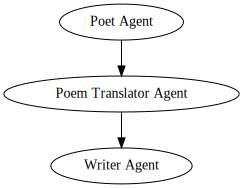

In [16]:
crew.plot()

Now run the crew end to end so each agent executes in dependency order.


In [17]:
crew.run()


RUNNING AGENT: Poet Agent

We search for the key in the lock of the bone,
To find the final purpose of being.
But the meaning is in the breath, in the tone,
In the act of love, in the healing.

It is not the distance we walk or the stone,
But the connection of the heart and mind.
To live is to let the light shine in the home,
And leave the life behind in the wind.

So walk the path where the others have stepped,
Not to find the answer in the sky.
But to find the truth in the heart and the kept,
When the light fades and the stars rise high.

RUNNING AGENT: Poem Translator Agent

我们在骨的锁孔里寻觅钥匙，
以求存在的终极归宿。
但意义在于呼吸，在于语调，
在爱的行为，在治愈之中。

不在于行走的距离或顽石，
而是心念连接的纽带。
活着，便是让光明在屋中闪耀，
将生命留给风去飘远。

故行他人曾踏足的路径，
不为在天空寻找答案。
只为在心底与坚守里探寻真理，
当光渐隐，星辰高悬天际。

RUNNING AGENT: Writer Agent


Thought: I need to write the Chinese poem from the context into a file called './poem.txt'. I'll use the write_str_to_txt tool with the poem content from the context.

Thought: [missing/Some models may skip <thought> tags]

Thou